## Importing libraries and Dataset

In [8]:
!pip install pandas
import pandas as pd 
import numpy as np

In [9]:
df = pd.read_csv("/Users/home/Documents/Projects/Email & SMS classifier/ml/processed_data.csv")
df.shape

(5169, 5)

In [10]:
df.head(3)

,target,text,num_characters,num_words,num_sentences
0,0,"Go until jurong point, crazy.. Available only ...",111,24,2
1,0,Ok lar... Joking wif u oni...,29,8,2
2,1,Free entry in 2 a wkly comp to win FA Cup fina...,155,37,2


## Text Preprocessing

In [11]:
!pip install scikit-learn nltk

In [12]:
import nltk
import ssl

# Fix SSL certificate issues (common on macOS)
try:
    _create_unverified_https_context = ssl._create_unverified_context
except AttributeError:
    pass
else:
    ssl._create_default_https_context = _create_unverified_https_context

# Remove quiet=True so you can see errors
result = nltk.download('punkt_tab')
print("Download success:", result)

Download success: True


[nltk_data] Downloading package punkt_tab to /Users/home/nltk_data...
[nltk_data]   Package punkt_tab is already up-to-date!


In [13]:
nltk.download('stopwords')

[nltk_data] Downloading package stopwords to /Users/home/nltk_data...
[nltk_data]   Unzipping corpora/stopwords.zip.


True

In [14]:
from nltk.corpus import stopwords
import string
from nltk.stem.porter import PorterStemmer


In [15]:
ps = PorterStemmer()

-----

## Creating & Applying The Transform Function

In [16]:
def transform_text(text):
    text = text.lower()
    text = nltk.word_tokenize(text)
    y = []
    for i in text:
        if i.isalnum():
            y.append(i)
            
    text = y[:]
    y.clear()
    
    for i in text:
        if i not in stopwords.words('english') and i not in string.punctuation:
            y.append(i)
            
    text = y[:]
    y.clear()
    
    for i in text:
        y.append(ps.stem(i))
        
    return " ".join(y)

In [17]:
df['transformed_text']=df["text"].apply(transform_text)

In [18]:
df.head(3)

,target,text,num_characters,num_words,num_sentences,transformed_text
0,0,"Go until jurong point, crazy.. Available only ...",111,24,2,go jurong point crazi avail bugi n great world...
1,0,Ok lar... Joking wif u oni...,29,8,2,ok lar joke wif u oni
2,1,Free entry in 2 a wkly comp to win FA Cup fina...,155,37,2,free entri 2 wkli comp win fa cup final tkt 21...


-----

## Counting the words Through The Word Cloud

In [19]:
!pip install wordcloud

In [20]:
from wordcloud import WordCloud
import matplotlib.pyplot as plt

In [21]:
wc = WordCloud(width=500,height=450,min_font_size=10,background_color='white')

## Spam Word Cloud

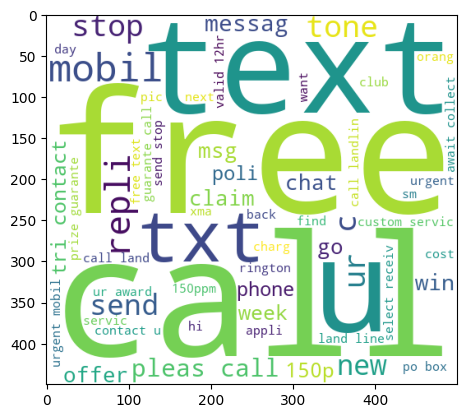

In [22]:
spam_wc = wc.generate(df[df['target'] == 1]['transformed_text'].str.cat(sep=' '))
plt.imshow(spam_wc)

## Ham Word Cloud

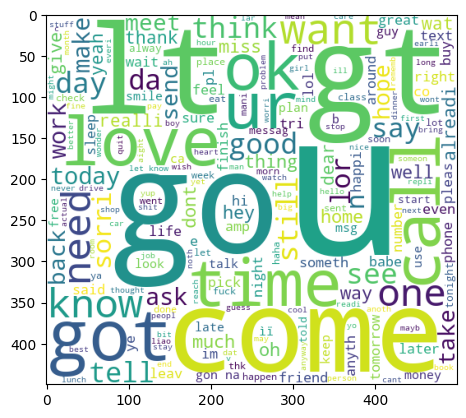

In [23]:
ham_wc = wc.generate(df[df['target'] == 0]['transformed_text'].str.cat(sep=' '))
plt.imshow(ham_wc)

-----

## Top 30 Spam Words

In [24]:
!pip install seaborn

In [25]:
from collections import Counter
import seaborn as sns

In [26]:
spam_corpus = []
for msg in df[df['target']==1]['transformed_text'].to_list():
    for word in msg.split():
        spam_corpus.append(word)

In [27]:
len(spam_corpus)

9939

In [28]:
pd.DataFrame(Counter(spam_corpus).most_common(30))[0]


0        call
1        free
2           2
3         txt
4        text
5           u
6          ur
7       mobil
8        stop
9       repli
10      claim
11          4
12      prize
13        get
14        new
15     servic
16       tone
17       send
18     urgent
19      nokia
20    contact
21      award
22      phone
23       cash
24      pleas
25       week
26        win
27          c
28    collect
29        min
Name: 0, dtype: str

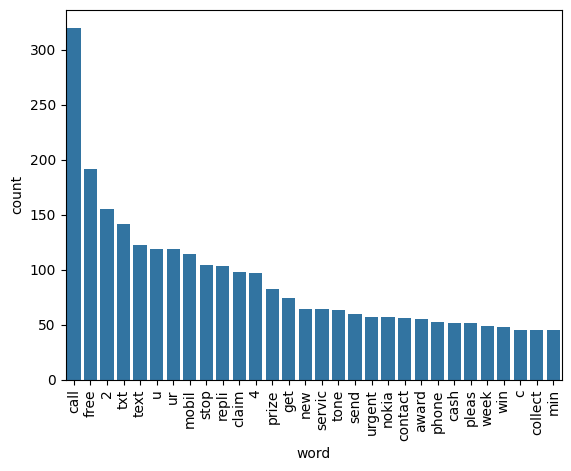

In [29]:
spam_df = pd.DataFrame(Counter(spam_corpus).most_common(30), columns=['word', 'count'])

sns.barplot(x=spam_df['word'], y=spam_df['count'])
plt.xticks(rotation='vertical')
plt.show()

-----

## Saving The Dataset

In [ ]:
df.to_csv("../ml/Text_Processed_Dataset.csv",index=False)